In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from anndata import AnnData
import scanpy as sc
output_fig = 'figures'

# Data exploration of the table used to annotate cell types
Questions:
1. The list of proteins that  are not used in the labelling are: 
    - 'EGFR',
    - 'Tbet', 
    - 'PD-L1',
    -  'CD366', 
    - 'HLA-DR-DQ-DP', 
    - 'VEGF', 
    - 'PD-1',
    -  'Collage-Type_I',
    -  'PD-L2', 
    - 'DNA2'
    
    I don't know all of them, but it seems strange that things like PD 1 are not used in the classification
2. The label 'Other cells', what does it refer to? How the markers have been chosen for this class?

 

Load the expert curated signature table

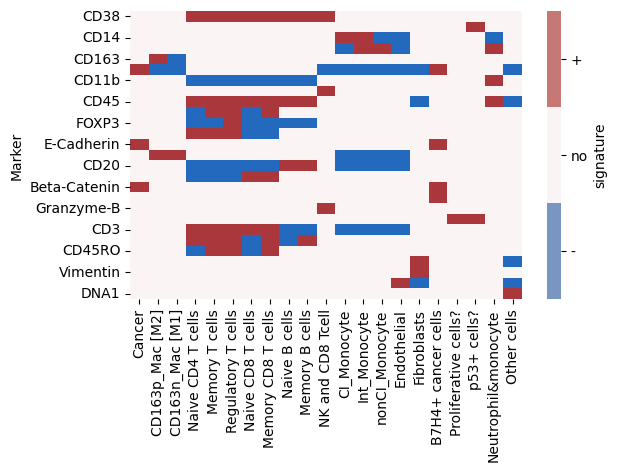

In [2]:

signature_sign = pd.read_csv('AnnoSpat/metadata/cell_type_matrix.csv',index_col=0).fillna(0)
marker_list = (signature_sign!=0).any(axis = 1)
marker_list = list(marker_list[marker_list].index)
ax = sns.heatmap(signature_sign.loc[marker_list],cbar_kws={"boundaries": np.linspace(-1, 1, 4)},cmap='vlag')
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([-0.667, 0, 0.667])
colorbar.set_ticklabels(['-', 'no', '+'])
colorbar.set_label('signature')
plt.tight_layout()
#plt.savefig(output_fig+'/signature.png')

list of proteins not used as markers

In [4]:
set((signature_sign!=0).any(axis = 1).index)-set(marker_list)
marker_list

['CD38',
 'p53',
 'CD14',
 'CD16',
 'CD163',
 'Pan-keratin',
 'CD11b',
 'CD107a',
 'CD45',
 'CD44',
 'FOXP3',
 'CD4',
 'E-Cadherin',
 'CD68',
 'CD20',
 'CD8a',
 'Beta-Catenin',
 'B7-H4',
 'Granzyme-B',
 'Ki-67',
 'CD3',
 'CD27',
 'CD45RO',
 'Alpha-SMA',
 'Vimentin',
 'CD31',
 'DNA1']

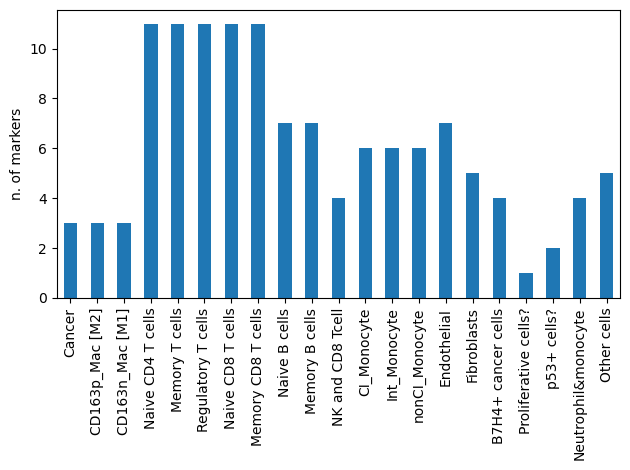

In [3]:
(signature_sign!=0).sum().plot(kind = 'bar')
plt.ylabel('n. of markers')
plt.tight_layout()
#plt.savefig(output_fig+'/num_markers_per_cell_type.png')

In [202]:
a = signature_sign[['Naive CD8 T cells',
       'Memory CD8 T cells']]
a[a.any(axis = 1)]

,Naive CD8 T cells,Memory CD8 T cells
Marker,,
CD38,1.0,1.0
CD11b,-1.0,-1.0
CD45,1.0,1.0
CD44,-1.0,1.0
FOXP3,-1.0,-1.0
CD4,-1.0,-1.0
CD20,-1.0,-1.0
CD8a,1.0,1.0
CD3,1.0,1.0


In [208]:
signature_sign.loc['CD107a'][signature_sign.loc['CD107a']!=0]

NK and CD8 Tcell    1.0
Name: CD107a, dtype: float64

In [195]:
cd8 = signature_sign.loc['CD8a']
cd8_pos = signature_sign[list(cd8[cd8>0].index)]#take cd8 positive types
print(cd8_pos[cd8_pos.iloc[:,0]!=cd8_pos.iloc[:,1]])
cd8_neg = signature_sign[list(cd8[cd8<0].index)]#take cd8 positive types
cd8_neg[(cd8_neg!=0).any(axis =1)]
print(cd8_neg[cd8_neg.iloc[:,0]!=cd8_neg.iloc[:,1]])

        Naive CD8 T cells  Memory CD8 T cells
Marker                                       
CD44                 -1.0                 1.0
CD27                 -1.0                 1.0
CD45RO               -1.0                 1.0
        Naive CD4 T cells  Memory T cells  Regulatory T cells
Marker                                                       
CD44                 -1.0             1.0                 1.0
CD45RO               -1.0             1.0                 1.0


In [93]:
cd3 = signature_sign.loc['CD3']
cd3_neg = signature_sign[list(cd3[cd3<0].index)]
cd3_neg = cd3_neg[(cd3_neg!=0).any(axis =1)]
cd20_pos = signature_sign.loc[:,(signature_sign.loc['CD20']>0).values]
cd20_pos = cd20_pos[(cd20_pos!=0).any(axis =1)]
cd20_pos[cd20_pos.iloc[:,0]!=cd20_pos.iloc[:,1]]

,Naive B cells,Memory B cells
Marker,,
CD27,-1.0,1.0


In [124]:
cd20_neg = signature_sign.loc[:,(signature_sign.loc['CD20']<0).values]
cd20_neg[(cd20_neg!=0).any(axis =1)]

,Naive CD4 T cells,Memory T cells,Regulatory T cells,Naive CD8 T cells,Memory CD8 T cells,CI_Monocyte,Int_Monocyte,nonCI_Monocyte,Endothelial
Marker,,,,,,,,,
CD38,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
CD14,0.0,0.0,0.0,0.0,0.0,1.0,1.0,-1.0,-1.0
CD16,0.0,0.0,0.0,0.0,0.0,-1.0,1.0,1.0,-1.0
Pan-keratin,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0
CD11b,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0
CD45,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
CD44,-1.0,1.0,1.0,-1.0,1.0,0.0,0.0,0.0,0.0
FOXP3,-1.0,-1.0,1.0,-1.0,-1.0,0.0,0.0,0.0,0.0
CD4,1.0,1.0,1.0,-1.0,-1.0,0.0,0.0,0.0,0.0


In [145]:
signature_sign.loc[:,signature_sign.loc[['CD16','CD14']].any()].loc[['CD16','CD14']]
a = signature_sign.loc[:,'Endothelial']
a[a!=0]

Marker
CD14          -1.0
CD16          -1.0
Pan-keratin   -1.0
CD68          -1.0
CD20          -1.0
CD3           -1.0
CD31           1.0
Name: Endothelial, dtype: float64

In [152]:
signature_sign[['Endothelial','Fibroblasts']][signature_sign[['Endothelial','Fibroblasts']].any(axis = 1)]

,Endothelial,Fibroblasts
Marker,,
CD14,-1.0,0.0
CD16,-1.0,0.0
Pan-keratin,-1.0,-1.0
CD45,0.0,-1.0
CD68,-1.0,0.0
CD20,-1.0,0.0
CD3,-1.0,0.0
Alpha-SMA,0.0,1.0
Vimentin,0.0,1.0


In [144]:
print(signature_sign.columns)
stuff_already_clustered = ['Cancer','CD163p_Mac [M2]', 'CD163n_Mac [M1]','Naive CD4 T cells','Memory T cells', 'Regulatory T cells', 'Naive CD8 T cells',
       'Memory CD8 T cells','Memory B cells','Naive B cells','CI_Monocyte', 'Int_Monocyte', 'nonCI_Monocyte']
set(signature_sign).difference(stuff_already_clustered)

Index(['Cancer', 'CD163p_Mac [M2]', 'CD163n_Mac [M1]', 'Naive CD4 T cells',
       'Memory T cells', 'Regulatory T cells', 'Naive CD8 T cells',
       'Memory CD8 T cells', 'Naive B cells', 'Memory B cells',
       'NK and CD8 Tcell', 'CI_Monocyte', 'Int_Monocyte', 'nonCI_Monocyte',
       'Endothelial', 'Fibroblasts', 'B7H4+ cancer cells',
       'Proliferative cells?', 'p53+ cells?', 'Neutrophil&monocyte',
       'Other cells'],
      dtype='object')


{'B7H4+ cancer cells',
 'Endothelial',
 'Fibroblasts',
 'NK and CD8 Tcell',
 'Neutrophil&monocyte',
 'Other cells',
 'Proliferative cells?',
 'p53+ cells?'}

In [193]:
#a = signature_sign.loc[:,signature_sign.loc[['CD44','CD45RO']].any()]
a = signature_sign[['Neutrophil&monocyte','nonCI_Monocyte']]
print(a[a.any(axis = 1)])


             Neutrophil&monocyte  nonCI_Monocyte
Marker                                          
CD14                        -1.0            -1.0
CD16                         1.0             1.0
Pan-keratin                  0.0            -1.0
CD11b                        1.0             0.0
CD45                         1.0             0.0
CD68                         0.0            -1.0
CD20                         0.0            -1.0
CD3                          0.0            -1.0


In [187]:
signature_sign.loc[['CD107a','CD38']].loc[:,signature_sign.loc[['CD107a','CD38']].any()]


,Naive CD4 T cells,Memory T cells,Regulatory T cells,Naive CD8 T cells,Memory CD8 T cells,Naive B cells,Memory B cells,NK and CD8 Tcell
Marker,,,,,,,,
CD107a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CD38,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [11]:

intensities = pd.read_csv('./pre_processed_files/all_data_intensities.csv')
intensities.index = intensities.index.astype(str)

columns_to_extract = intensities.columns.difference(['slice_ID'])
intensities_protein = intensities[columns_to_extract]#contains only numeric values (intensities)

regions = pd.read_csv('./pre_processed_files/all_data_regions.csv',index_col=0)
labels = pd.read_csv('output/trte_labels_ELM_IMC_T1D_AnnoSpat.csv')
num_labels = pd.read_csv('output/trte_labels_numericLabels_ELM_IMC_T1D_AnnoSpat.csv')
mapper = dict(zip(num_labels.label,labels.label))#convert numeric labels to cell types

#adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})
#adata.obs['AnnoSpat'] = num_labels.label.values.astype(str)


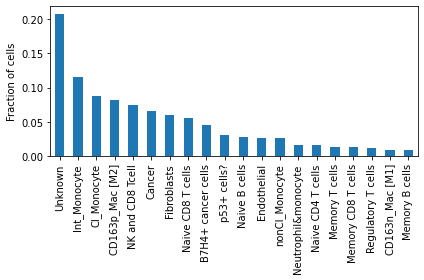

In [14]:
labels.label.value_counts(normalize=True).plot(kind = 'bar')
plt.tight_layout()
plt.ylabel('Fraction of cells')
plt.tight_layout()
#plt.savefig('figures/label_density.png')

In [28]:
labels.label.value_counts(normalize=True)

Other cells             0.189054
p53+ cells?             0.141631
Memory B cells          0.099154
Naive CD8 T cells       0.064621
Regulatory T cells      0.050025
Unknown                 0.041650
Proliferative cells?    0.041133
nonCI_Monocyte          0.036997
Cancer                  0.035171
Fibroblasts             0.032620
Endothelial             0.031500
Memory CD8 T cells      0.029691
Naive CD4 T cells       0.028778
Naive B cells           0.026848
NK and CD8 Tcell        0.026021
Neutrophil&monocyte     0.024384
CD163n_Mac [M1]         0.023763
Memory T cells          0.021058
B7H4+ cancer cells      0.020007
CD163p_Mac [M2]         0.013010
CI_Monocyte             0.012924
Int_Monocyte            0.009960
Name: label, dtype: float64